<a href="https://colab.research.google.com/github/rjlobosco/unifesp/blob/main/Aula_8_Newton_Secantes_Calculo_Numerico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Método de Newton e método das secantes

Nesta aula vamos aproximar raízes de equações não lineares. Primeiro construiremos o método de Newton a partir da reta tangente; depois veremos como o método das secantes aproveita duas aproximações para evitar o cálculo explícito da derivada. Ao final, compararemos convergência, custo e limitações em uma aplicação de engenharia.

**Objetivos de aprendizagem**

- interpretar geometricamente as iterações de Newton e das secantes;
- implementar ambos os métodos em Python;
- definir e interpretar critérios de parada;
- comparar número de iterações, resíduos e sensibilidade à estimativa inicial;
- escolher um método adequado para uma equação não linear simples.


## 1. O problema de encontrar uma raiz

Queremos encontrar um número $r$ tal que

$$f(r)=0.$$

Em muitos problemas, a equação não pode ser resolvida de forma simples por manipulação algébrica. Um método numérico constrói uma sequência de aproximações $x_0,x_1,x_2,\ldots$ que esperamos que se aproxime da raiz.

A cada iteração podemos verificar o **resíduo** $|f(x_k)|$. Um resíduo pequeno indica que $x_k$ satisfaz aproximadamente a equação, mas não garante por si só que a distância até a raiz seja pequena em qualquer problema. Também observaremos o tamanho do passo $|x_{k+1}-x_k|$.

In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True


## O que significa encontrar uma raiz?

Uma **raiz** é um valor de \(x\) que faz a função valer zero. Por exemplo, para

$$
f(x)=x^2-4,
$$

as raízes são \(x=-2\) e \(x=2\), pois \(f(-2)=0\) e \(f(2)=0\).

Em muitos problemas de engenharia, a equação não tem uma solução fácil de calcular diretamente. Nesse caso, começamos com uma estimativa inicial, chamada \(x_0\), e usamos um método numérico para construir novas aproximações:

$$
x_0,\;x_1,\;x_2,\;x_3,\ldots
$$

Esperamos que essa sequência se aproxime de uma raiz.

### Resíduo e tamanho do passo

Em cada aproximação \(x_k\), podemos calcular o **resíduo**:

$$
|f(x_k)|.
$$

O resíduo mede quanto a função ainda está distante de zero naquela aproximação. Por exemplo, se \(f(x_k)=0,001\), então o resíduo é \(0,001\). Em geral, um resíduo pequeno indica que \(x_k\) satisfaz a equação aproximadamente.

Também podemos calcular o tamanho do passo entre duas aproximações consecutivas:

$$
|x_{k+1}-x_k|.
$$

Se esse valor for pequeno, o método está alterando pouco a estimativa entre uma iteração e outra. Porém, um passo pequeno, sozinho, não garante que encontramos uma raiz. Por isso, é importante acompanhar tanto o resíduo quanto o tamanho do passo.

---

## Como surge o método de Newton?

Imagine o gráfico de uma função e uma aproximação atual \(x_k\). No ponto do gráfico correspondente a \(x_k\), traçamos uma **reta tangente**. Perto desse ponto, a reta tangente pode servir como uma aproximação local da função.

A equação da reta tangente ao gráfico de \(y=f(x)\), no ponto \(x_k\), é:

$$
y=f(x_k)+f'(x_k)(x-x_k).
$$

Para estimar onde essa reta cruza o eixo horizontal, fazemos \(y=0\):

$$
0=f(x_k)+f'(x_k)(x_{k+1}-x_k).
$$

Agora isolamos \(x_{k+1}\):

$$
x_{k+1}=x_k-\frac{f(x_k)}{f'(x_k)}.
$$

Essa é a fórmula do **método de Newton**. A cada iteração, a nova aproximação é o ponto em que a reta tangente atual cruza o eixo \(x\).

### Exemplo

Considere:

$$
f(x)=x^2-4.
$$

As raízes são \(x=-2\) e \(x=2\). Vamos procurar a raiz positiva, começando com \(x_0=3\).

A derivada da função é:

$$
f'(x)=2x.
$$

Na primeira iteração:

$$
f(3)=3^2-4=5,
$$

e

$$
f'(3)=2(3)=6.
$$

Aplicando a fórmula de Newton:

$$
x_1=3-\frac{5}{6}\approx 2{,}167.
$$

A nova estimativa está mais perto da raiz \(x=2\). Repetindo o processo, obtemos aproximadamente:

$$
x_2\approx 2,006,
\qquad
x_3\approx 2,000.
$$

### Por que a derivada importa?

A derivada \(f'(x_k)\) representa a inclinação do gráfico no ponto atual. Se \(f'(x_k)=0\), não podemos aplicar a fórmula, pois ela exigiria uma divisão por zero. Se a derivada for muito pequena, o passo calculado pode ser muito grande e levar a uma estimativa distante da raiz.

O método também depende da aproximação inicial. Uma tangente pode cruzar o eixo \(x\) longe da raiz desejada, e as aproximações podem não convergir. Por isso, devemos acompanhar as iterações e verificar se o resíduo está suficientemente pequeno.



### Exemplo guiado

Vamos aproximar a raiz de $f(x)=\cos(x)-x$. A raiz está entre 0 e 1, pois $f(0)>0$ e $f(1)<0$. A derivada é $f'(x)=-\sin(x)-1$.

Use $x_0=0.5$ e calcule duas iterações . Em cada linha registre $x_k$, $f(x_k)$, $f'(x_k)$ e $x_{k+1}$.

In [3]:
import math
def f_cosseno(x):
    return math.cos(x) - x

def df_cosseno(x):
    return -math.sin(x) - 1

x = 0.5
for k in range(2):
    x_next = x - f_cosseno(x) / df_cosseno(x)
    print(f"k={k}: x_k={x:.10f}, f(x_k)={f_cosseno(x):.3e}, x_(k+1)={x_next:.10f}")
    x = x_next

k=0: x_k=0.5000000000, f(x_k)=3.776e-01, x_(k+1)=0.7552224171
k=1: x_k=0.7552224171, f(x_k)=-2.710e-02, x_(k+1)=0.7391416661


### Visualização das tangentes

O gráfico mostra a função e as tangentes usadas nas primeiras iterações. O ponto em que cada tangente cruza o eixo horizontal é a próxima aproximação de Newton.

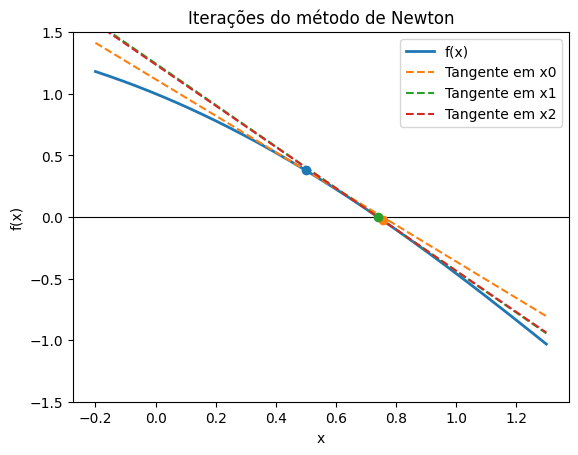

In [6]:
import numpy as np
import matplotlib.pyplot as plt
def plot_newton_steps(f, df, x0, n=3, xlim=(-0.2, 1.3)):
    xs = np.linspace(xlim[0], xlim[1], 500)
    plt.figure()
    plt.plot(xs, [f(x) for x in xs], label="f(x)", linewidth=2)
    plt.axhline(0, color="black", linewidth=0.8)
    x = float(x0)
    for k in range(n):
        y = f(x)
        slope = df(x)
        plt.scatter([x], [y], zorder=3)
        tangent = y + slope * (xs - x)
        plt.plot(xs, tangent, "--", label=f"Tangente em x{k}")
        x = x - y / slope
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.title("Iterações do método de Newton")
    plt.ylim(-1.5, 1.5)
    plt.legend()
    plt.show()

plot_newton_steps(f_cosseno, df_cosseno, x0=0.5, n=3)


## 3. Implementação do método de Newton

Usaremos dois controles:

- **tolerância do resíduo**: aceitar uma aproximação quando $|f(x_k)|\leq\text{tol}$;
- **número máximo de iterações**: impedir uma execução indefinida.

Também verificaremos se a derivada é muito próxima de zero. Retornaremos o histórico para que possamos inspecionar cada aproximação.

In [8]:
import pandas as pd
def newton(f, df, x0, tol=1e-10, max_iter=50, deriv_tol=1e-14):
    """Resolve f(x)=0 pelo método de Newton e retorna raiz e histórico."""
    x = float(x0)
    historico = []

    for k in range(max_iter):
        fx = f(x)
        dfx = df(x)
        historico.append({"k": k, "x": x, "f(x)": fx, "f'(x)": dfx})

        if abs(fx) <= tol:
            return x, historico, "convergiu pelo resíduo"

        if abs(dfx) <= deriv_tol:
            return x, historico, "parou: derivada nula ou muito pequena"

        x_novo = x - fx / dfx

        # Um passo pequeno sem resíduo pequeno pode indicar estagnação.
        if abs(x_novo - x) <= tol * max(1.0, abs(x_novo)):
            x = x_novo
            if abs(f(x)) <= tol:
                historico.append({"k": k + 1, "x": x, "f(x)": f(x), "f'(x)": df(x)})
                return x, historico, "convergiu pelo resíduo após passo pequeno"
            return x, historico, "parou: passo pequeno, mas resíduo ainda alto"

        x = x_novo

    return x, historico, "parou: atingiu o máximo de iterações"

raiz_n, hist_n, estado_n = newton(f_cosseno, df_cosseno, x0=0.5)
print("Raiz aproximada:", raiz_n)
print("Resíduo:", abs(f_cosseno(raiz_n)))
print("Iterações registradas:", len(hist_n))
print("Estado:", estado_n)
pd.DataFrame(hist_n)

Raiz aproximada: 0.7390851332151607
Resíduo: 0.0
Iterações registradas: 5
Estado: convergiu pelo resíduo


,k,x,f(x),f'(x)
0,0,0.500000,3.775826e-01,-1.479426
1,1,0.755222,-2.710331e-02,-1.685451
2,2,0.739142,-9.461538e-05,-1.673654
3,3,0.739085,-1.180978e-09,-1.673612
4,4,0.739085,0.000000e+00,-1.673612


## 4. Convergência e escolhas numéricas

Quando Newton está suficientemente perto de uma raiz simples e a função é suave, costuma apresentar **convergência quadrática**: aproximadamente, o número de algarismos corretos dobra a cada iteração. Essa rapidez local não significa que qualquer estimativa inicial funcionará.

Problemas possíveis:

- $f'(x_k)=0$ ou muito pequeno;
- a tangente leva a uma região distante da raiz;
- a sequência oscila ou diverge;
- uma raiz múltipla reduz a velocidade de convergência;
- erros de arredondamento afetam cálculos em precisão finita.

A tolerância controla a precisão solicitada ao algoritmo, não a precisão física dos dados do problema.

In [9]:
# Sensibilidade da raiz de cos(x)-x a diferentes aproximações iniciais
for chute in [0.1, 0.5, 1.2, -2.0]:
    raiz, hist, estado = newton(f_cosseno, df_cosseno, x0=chute)
    print(f"x0={chute:5.2f} -> raiz={raiz:.12f}, |f|={abs(f_cosseno(raiz)):.2e}, n={len(hist)}, {estado}")


x0= 0.10 -> raiz=0.739085133225, |f|=1.73e-11, n=5, convergiu pelo resíduo
x0= 0.50 -> raiz=0.739085133215, |f|=0.00e+00, n=5, convergiu pelo resíduo
x0= 1.20 -> raiz=0.739085133215, |f|=0.00e+00, n=5, convergiu pelo resíduo
x0=-2.00 -> raiz=0.739085133216, |f|=1.07e-12, n=7, convergiu pelo resíduo


### Atividade rápida — Newton

1. Troque a tolerância para $10^{-4}$ e depois $10^{-10}$. Quantas iterações são necessárias em cada caso?
2. Teste $f(x)=x^2-2$ com $x_0=0$. O que acontece? Relacione o resultado à derivada.
3. Teste $f(x)=(x-1)^2$ com $x_0=2$. Compare a redução do erro com o caso de uma raiz simples.

## 5. Método das secantes

O método das secantes aproxima a derivada usando dois pontos:

$$f'(x_k)\approx\frac{f(x_k)-f(x_{k-1})}{x_k-x_{k-1}}.$$

Substituindo essa aproximação na fórmula de Newton, obtemos

$$x_{k+1}=x_k-f(x_k)\frac{x_k-x_{k-1}}{f(x_k)-f(x_{k-1})}.$$

O método precisa de **duas estimativas iniciais**, mas não exige a expressão de $f'(x)$. O denominador deve ser diferente de zero. Em geral, a convergência é superlinear (ordem aproximada 1,618) perto de uma raiz simples, mais lenta que Newton, mas pode ser útil quando a derivada é difícil de calcular.

### Construção geométrica

Em vez da tangente em um ponto, usamos a reta que passa por $(x_{k-1},f(x_{k-1}))$ e $(x_k,f(x_k))$. A interseção dessa reta com o eixo horizontal fornece $x_{k+1}$.

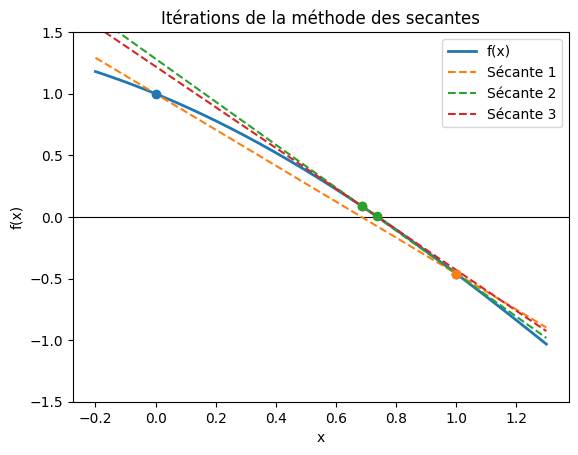

In [10]:
def plot_secant_steps(f, x0, x1, n=3, xlim=(-0.2, 1.3)):
    xs = np.linspace(xlim[0], xlim[1], 500)
    plt.figure()
    plt.plot(xs, [f(x) for x in xs], label="f(x)", linewidth=2)
    plt.axhline(0, color="black", linewidth=0.8)
    a, b = float(x0), float(x1)
    for k in range(n):
        fa, fb = f(a), f(b)
        plt.scatter([a, b], [fa, fb], zorder=3)
        if fb == fa:
            break
        slope = (fb - fa) / (b - a)
        secant = fb + slope * (xs - b)
        plt.plot(xs, secant, "--", label=f"Sécante {k+1}")
        c = b - fb / slope
        a, b = b, c
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.title("Itérations de la méthode des secantes")
    plt.ylim(-1.5, 1.5)
    plt.legend()
    plt.show()

plot_secant_steps(f_cosseno, x0=0.0, x1=1.0, n=3)


## 6. Implementação do método das secantes

A implementação guarda o valor da função em cada aproximação, verifica a tolerância do resíduo e interrompe a execução se o denominador ficar muito pequeno.

In [11]:
def secantes(f, x0, x1, tol=1e-10, max_iter=50, denom_tol=1e-14):
    """Resolve f(x)=0 pelo método das secantes."""
    x_anterior = float(x0)
    x_atual = float(x1)
    historico = []

    for k in range(max_iter):
        f_anterior = f(x_anterior)
        f_atual = f(x_atual)
        historico.append({"k": k, "x": x_atual, "f(x)": f_atual})

        if abs(f_atual) <= tol:
            return x_atual, historico, "convergiu pelo resíduo"

        denominador = f_atual - f_anterior
        if abs(denominador) <= denom_tol:
            return x_atual, historico, "parou: denominador nulo ou muito pequeno"

        x_novo = x_atual - f_atual * (x_atual - x_anterior) / denominador

        if abs(x_novo - x_atual) <= tol * max(1.0, abs(x_novo)):
            if abs(f(x_novo)) <= tol:
                historico.append({"k": k + 1, "x": x_novo, "f(x)": f(x_novo)})
                return x_novo, historico, "convergiu pelo resíduo após passo pequeno"
            return x_novo, historico, "parou: passo pequeno, mas resíduo ainda alto"

        x_anterior, x_atual = x_atual, x_novo

    return x_atual, historico, "parou: atingiu o máximo de iterações"

raiz_s, hist_s, estado_s = secantes(f_cosseno, x0=0.0, x1=1.0)
print("Raiz aproximada:", raiz_s)
print("Resíduo:", abs(f_cosseno(raiz_s)))
print("Iterações registradas:", len(hist_s))
print("Estado:", estado_s)
pd.DataFrame(hist_s)


Raiz aproximada: 0.7390851332150012
Resíduo: 2.667865928174251e-13
Iterações registradas: 6
Estado: convergiu pelo resíduo


,k,x,f(x)
0,0,1.000000,-4.596977e-01
1,1,0.685073,8.929928e-02
2,2,0.736299,4.660039e-03
3,3,0.739119,-5.728599e-05
4,4,0.739085,3.529262e-08
5,5,0.739085,2.667866e-13


## 8. Comparação dos métodos

Para comparar de forma justa, precisamos olhar além da rapidez: verificamos se os métodos chegaram a uma raiz, o resíduo final e o número de iterações. O número de iterações não representa sozinho o custo total: Newton calcula a derivada, enquanto secantes avalia a função e atualiza uma inclinação aproximada.

# Comparação entre o método de Newton e o método das secantes

Vamos comparar dois métodos para encontrar a raiz da função

$$
f(x)=\cos(x)-x.
$$

A raiz está entre 0 e 1, porque

$$
f(0)=1>0
\qquad\text{e}\qquad
f(1)=\cos(1)-1<0.
$$

O método de Newton usa uma estimativa inicial e a derivada:

$$
x_{k+1}=x_k-\frac{f(x_k)}{f'(x_k)}.
$$

Neste exemplo,

$$
f'(x)=-\sin(x)-1.
$$

O método das secantes não calcula a derivada. Ele estima a inclinação usando duas aproximações:

$$
x_{k+1}
=
x_k
-
f(x_k)\frac{x_k-x_{k-1}}{f(x_k)-f(x_{k-1})}.
$$

Usaremos $x_0=0{,}5$ para Newton e $x_0=0$, $x_1=1$ para as secantes. Vamos comparar as aproximações geradas, o resíduo $|f(x_k)|$ e o número de atualizações.

**Observação:** Newton começa com uma estimativa; as secantes precisam de duas. Por isso, o número de atualizações deve ser interpretado junto com o custo de calcular a derivada e as avaliações da função.

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define a função cuja raiz queremos encontrar.
def f(x):
    return np.cos(x) - x

# Derivada necessária para o método de Newton.
def df(x):
    return -np.sin(x) - 1


def metodo_newton(f, df, x0, tolerancia=1e-10, max_iter=50):
    """
    Aplica o método de Newton.

    Retorna:
    - as aproximações x_k;
    - os resíduos |f(x_k)|.
    """
    aproximacoes = [float(x0)]
    residuos = [abs(f(x0))]
    x = float(x0)

    for k in range(max_iter):
        fx = f(x)
        dfx = df(x)

        # Evita divisão por zero ou por um número muito pequeno.
        if abs(dfx) < 1e-14:
            print("Newton parou: derivada nula ou muito pequena.")
            break

        # Se o resíduo já está abaixo da tolerância, terminamos.
        if abs(fx) <= tolerancia:
            break

        # Calcula a próxima aproximação.
        x_novo = x - fx / dfx
        aproximacoes.append(x_novo)
        residuos.append(abs(f(x_novo)))

        x = x_novo

        if abs(f(x)) <= tolerancia:
            break

    return aproximacoes, residuos


def metodo_secantes(f, x0, x1, tolerancia=1e-10, max_iter=50):
    """
    Aplica o método das secantes.

    Retorna:
    - as aproximações x_k;
    - os resíduos |f(x_k)|.
    """
    x_anterior = float(x0)
    x_atual = float(x1)

    aproximacoes = [x_anterior, x_atual]
    residuos = [abs(f(x_anterior)), abs(f(x_atual))]

    for k in range(max_iter):
        f_anterior = f(x_anterior)
        f_atual = f(x_atual)

        # Se já atingimos a tolerância, terminamos.
        if abs(f_atual) <= tolerancia:
            break

        denominador = f_atual - f_anterior

        # Evita divisão por um denominador muito pequeno.
        if abs(denominador) < 1e-14:
            print("Secantes parou: denominador nulo ou muito pequeno.")
            break

        # Calcula a próxima aproximação.
        x_novo = x_atual - f_atual * (x_atual - x_anterior) / denominador

        aproximacoes.append(x_novo)
        residuos.append(abs(f(x_novo)))

        # Desloca os pontos para a próxima iteração.
        x_anterior = x_atual
        x_atual = x_novo

        if abs(f(x_atual)) <= tolerancia:
            break

    return aproximacoes, residuos

In [17]:
# Executa os métodos com as aproximações iniciais escolhidas.
xs_newton, res_newton = metodo_newton(
    f=f,
    df=df,
    x0=0.5
)

xs_secantes, res_secantes = metodo_secantes(
    f=f,
    x0=0.0,
    x1=1.0
)

# Organiza os resultados principais em uma tabela.
raiz_newton = xs_newton[-1]
raiz_secantes = xs_secantes[-1]

comparacao = pd.DataFrame({
    "Método": ["Newton", "Secantes"],
    "Aproximação da raiz": [raiz_newton, raiz_secantes],
    "Resíduo final": [abs(f(raiz_newton)), abs(f(raiz_secantes))],
    "Atualizações calculadas": [
        len(xs_newton) - 1,
        len(xs_secantes) - 2
    ]
})

comparacao

,Método,Aproximação da raiz,Resíduo final,Atualizações calculadas
0,Newton,0.739085,0.000000e+00,4
1,Secantes,0.739085,2.667866e-13,5


### Como interpretar a tabela

A aproximação final de cada método deve estar próxima da raiz da equação. O resíduo final indica quanto a função ainda se afasta de zero nessa aproximação.

Newton costuma convergir rapidamente quando a estimativa inicial está adequada e a derivada está disponível. O método das secantes evita calcular a derivada, mas precisa de duas aproximações iniciais.

O número de atualizações não conta toda a história do custo computacional: em Newton também precisamos avaliar a derivada; nas secantes, precisamos começar com dois valores e avaliar a função. O melhor método depende do problema e das informações disponíveis.

In [18]:
# Monta uma tabela com as aproximações de cada método.
tabela_newton = pd.DataFrame({
    "Iteração": range(len(xs_newton)),
    "x_k": xs_newton,
    "|f(x_k)|": res_newton
})
tabela_newton["Método"] = "Newton"

tabela_secantes = pd.DataFrame({
    "Iteração": range(len(xs_secantes)),
    "x_k": xs_secantes,
    "|f(x_k)|": res_secantes
})
tabela_secantes["Método"] = "Secantes"

tabela_iteracoes = pd.concat(
    [tabela_newton, tabela_secantes],
    ignore_index=True
)

tabela_iteracoes[["Método", "Iteração", "x_k", "|f(x_k)|"]]

,Método,Iteração,x_k,|f(x_k)|
0,Newton,0,0.500000,3.775826e-01
1,Newton,1,0.755222,2.710331e-02
2,Newton,2,0.739142,9.461538e-05
3,Newton,3,0.739085,1.180978e-09
4,Newton,4,0.739085,0.000000e+00
5,Secantes,0,0.000000,1.000000e+00
6,Secantes,1,1.000000,4.596977e-01
7,Secantes,2,0.685073,8.929928e-02
8,Secantes,3,0.736299,4.660039e-03
9,Secantes,4,0.739119,5.728599e-05


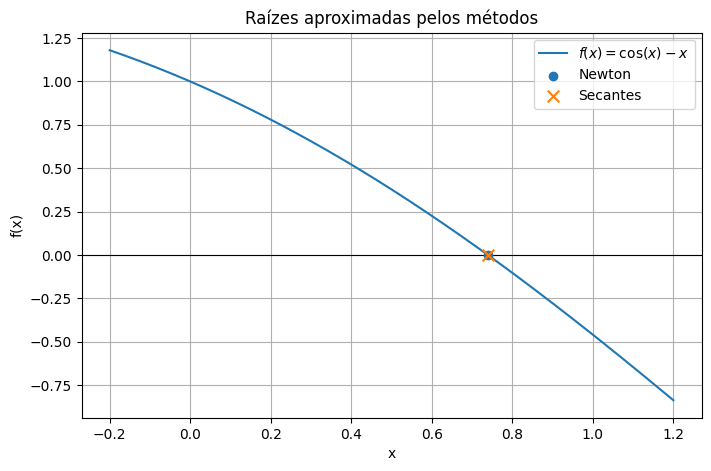

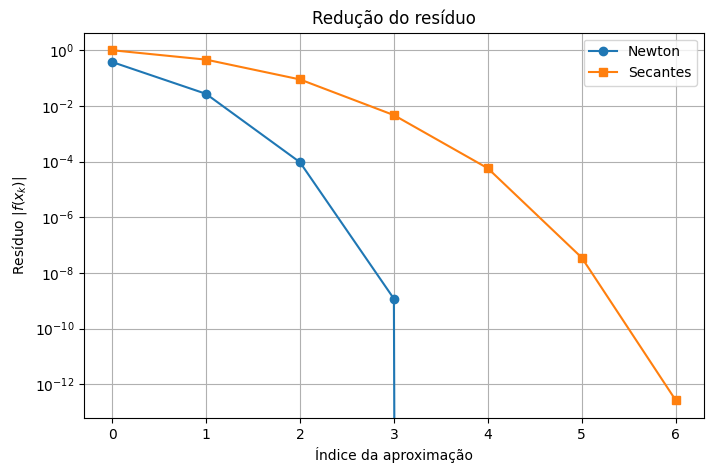

In [19]:
# Gráfico da função e da raiz aproximada.
x_plot = np.linspace(-0.2, 1.2, 400)
y_plot = f(x_plot)

plt.figure(figsize=(8, 5))
plt.plot(x_plot, y_plot, label=r"$f(x)=\cos(x)-x$")
plt.axhline(0, color="black", linewidth=0.8)
plt.scatter([raiz_newton], [f(raiz_newton)], label="Newton", zorder=3)
plt.scatter([raiz_secantes], [f(raiz_secantes)], marker="x",
            s=70, label="Secantes", zorder=3)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Raízes aproximadas pelos métodos")
plt.grid(True)
plt.legend()
plt.show()


# Gráfico dos resíduos ao longo das iterações.
plt.figure(figsize=(8, 5))
plt.semilogy(range(len(res_newton)), res_newton, "o-", label="Newton")
plt.semilogy(range(len(res_secantes)), res_secantes, "s-", label="Secantes")
plt.xlabel("Índice da aproximação")
plt.ylabel(r"Resíduo $|f(x_k)|$")
plt.title("Redução do resíduo")
plt.grid(True, which="both")
plt.legend()
plt.show()

# O método babilônico como caso particular do método de Newton

O método babilônico calcula aproximações para a raiz quadrada de um número positivo $a$. Para obter $\sqrt{a}$ numericamente, podemos procurar a raiz da função

$$
f(x)=x^2-a.
$$

Encontrar uma raiz dessa função significa encontrar um valor $x$ tal que

$$
x^2-a=0,
$$

ou seja,

$$
x^2=a.
$$

A derivada da função é

$$
f'(x)=2x.
$$

Aplicamos a fórmula de Newton:

$$
x_{k+1}=x_k-\frac{f(x_k)}{f'(x_k)}.
$$

Substituindo $f(x_k)=x_k^2-a$ e $f'(x_k)=2x_k$:

$$
x_{k+1}
=
x_k-\frac{x_k^2-a}{2x_k}.
$$

Escrevemos $x_k$ com denominador $2x_k$:

$$
x_{k+1}
=
\frac{2x_k^2}{2x_k}
-
\frac{x_k^2-a}{2x_k}.
$$

Combinando os termos:

$$
x_{k+1}
=
\frac{2x_k^2-x_k^2+a}{2x_k}
=
\frac{x_k^2+a}{2x_k}.
$$

Separando a fração:

$$
\boxed{
x_{k+1}
=
\frac{1}{2}
\left(
x_k+\frac{a}{x_k}
\right)
}
$$

Essa é a fórmula do **método babilônico**. Portanto, o método babilônico para calcular $\sqrt{a}$ é exatamente o método de Newton aplicado à equação $f(x)=x^2-a$.

É necessário começar com $x_0>0$, pois a fórmula divide por $x_k$. Para $a>0$, uma estimativa positiva adequada costuma produzir aproximações cada vez mais próximas de $\sqrt{a}$.

In [20]:
# Exemplo: aproximar a raiz quadrada de a.
a = 10.0
x0 = 3.0

def g(x):
    return x**2 - a

def dg(x):
    return 2*x

# Próximo passo obtido pelo método geral de Newton.
x1_newton = x0 - g(x0) / dg(x0)

# Mesmo passo escrito pela fórmula do método babilônico.
x1_babilonico = 0.5 * (x0 + a / x0)

print(f"a = {a}")
print(f"x0 = {x0}")
print(f"Passo de Newton:     x1 = {x1_newton:.10f}")
print(f"Fórmula babilônica:  x1 = {x1_babilonico:.10f}")
print(f"sqrt(a), calculada pela biblioteca: {np.sqrt(a):.10f}")

a = 10.0
x0 = 3.0
Passo de Newton:     x1 = 3.1666666667
Fórmula babilônica:  x1 = 3.1666666667
sqrt(a), calculada pela biblioteca: 3.1622776602


O gráfico abaixo mostra a parábola \(g(x)=x^2-a\) e a reta tangente no ponto correspondente a \(x_0\). A interseção dessa tangente com o eixo horizontal fornece \(x_1\), a primeira aproximação do método babilônico.

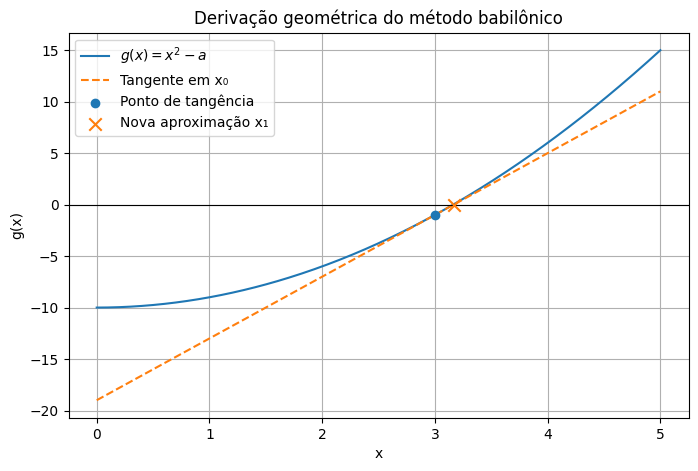

In [21]:
x_plot = np.linspace(0, 5, 400)
y_plot = g(x_plot)

# Reta tangente a g no ponto x0.
tangente = g(x0) + dg(x0) * (x_plot - x0)

plt.figure(figsize=(8, 5))
plt.plot(x_plot, y_plot, label=r"$g(x)=x^2-a$")
plt.plot(x_plot, tangente, "--", label="Tangente em x₀")
plt.axhline(0, color="black", linewidth=0.8)
plt.scatter([x0], [g(x0)], label="Ponto de tangência", zorder=3)
plt.scatter([x1_newton], [0], marker="x", s=80,
            label="Nova aproximação x₁", zorder=3)
plt.xlabel("x")
plt.ylabel("g(x)")
plt.title("Derivação geométrica do método babilônico")
plt.grid(True)
plt.legend()
plt.show()

In [22]:
# Aplica repetidamente a fórmula babilônica.
a = 10.0
x = 3.0
historico = []

for k in range(10):
    erro = abs(x - np.sqrt(a))
    residuo = abs(x**2 - a)

    historico.append({
        "Iteração": k,
        "x_k": x,
        "Resíduo |x_k²-a|": residuo,
        "Erro |x_k-sqrt(a)|": erro
    })

    # Próxima aproximação babilônica.
    x = 0.5 * (x + a / x)

tabela_babilonico = pd.DataFrame(historico)
tabela_babilonico

,Iteração,x_k,Resíduo |x_k²-a|,Erro |x_k-sqrt(a)|
0,0,3.000000,1.000000e+00,1.622777e-01
1,1,3.166667,2.777778e-02,4.389006e-03
2,2,3.162281,1.923669e-05,3.041586e-06
3,3,3.162278,9.249490e-12,1.462386e-12
4,4,3.162278,1.776357e-15,4.440892e-16
5,5,3.162278,1.776357e-15,4.440892e-16
6,6,3.162278,1.776357e-15,4.440892e-16
7,7,3.162278,1.776357e-15,4.440892e-16
8,8,3.162278,1.776357e-15,4.440892e-16
9,9,3.162278,1.776357e-15,4.440892e-16


## 11. Síntese

- **Newton:** uma estimativa inicial e uma derivada; normalmente muito rápido perto de uma raiz simples, mas sensível à estimativa inicial e a derivadas pequenas.
- **Secantes:** duas estimativas iniciais e nenhuma derivada explícita; convergência usualmente superlinear perto de raiz simples, com possíveis problemas quando valores consecutivos de $f$ são quase iguais.
- **Em ambos:** escolha a tolerância com critério, acompanhe resíduo e passos, defina um máximo de iterações e interprete a raiz no contexto físico.

**Pergunta de saída:** qual dos dois métodos você usaria para resolver uma equação de engenharia cuja derivada é difícil de obter? Cite uma vantagem e um risco da sua escolha.